In [3]:
# ==============================================================
# CLASSIFICATION BINAIRE MULTICRITÈRE (PyTorch + M2 Pro GPU)
# ==============================================================
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import re

from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE



from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [3]:
# --------------------------------------------------------------
# 1️. CONFIGURATION GPU MPS
# --------------------------------------------------------------
print("="*70)
print("CONFIGURATION GPU APPLE M2 PRO")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")
print(f"MPS compilé: {torch.backends.mps.is_built()}")

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"✅ Utilisation du device : {device}")
print("="*70, "\n")

CONFIGURATION GPU APPLE M2 PRO
PyTorch version: 2.4.1
MPS disponible: True
MPS compilé: True
✅ Utilisation du device : mps



### Étape A — Ingestion + typage + nettoyage

#### Ingestion 

In [11]:
# 2. CHARGEMENT DU FICHIER ------------------------------------------------
df_fact_acorig = pd.read_csv("data/fisprod_acorriger20260131.csv", sep=',', header=0)
df_fact_valide= pd.read_csv("data/fisprod_valider20260131.csv", sep=',', header=0)
df = pd.concat([df_fact_valide, df_fact_acorig], ignore_index=True, axis=0)
data=df.copy()
colonnes_all=df.columns
#df.head

/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_20741/4041116095.py:3: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fact_valide= pd.read_csv("data/fisprod_valider20260131.csv", sep=',', header=0)


In [12]:
colonnes_all

Index(['id_structure', 'nom_patient', 'village', 'distance_village',
       'age_patient', 'sex', 'parent_name', 'tel', 'visit_date',
       'serie_number', 'registre_number', 'consultation_type',
       'type_prestation', 'num_ordonance', 'quantite_total_prod',
       'quantite_total_act', 'quantite_total_ex', 'cout_total_prod',
       'cout_total_act', 'cout_total_ex', 'type_observation', 'nbre_jours',
       'cout_mise_en_observation', 'cout_evacuation', 'nbre_kilomettre',
       'user_id', 'is_delete', 'id_user_created', 'id_user_updated',
       'id_user_deleted', 'deleted_at', 'created_at', 'updated_at',
       'assurance', 'taux_assurance', 'id', 'structure_assurance',
       'id_prescripteur', 'id_gerant', 'id_village', 'date_entree',
       'date_sortie', 'mode_sortie', 'data_source', 'id_api',
       'mobile_app_version', 'status_verification',
       'observations_verification', 'date_verification',
       'libelle_consultation_type', 'libelle_type_prestation', 'user_name',


In [18]:
print(df['libelle_type_structure'].unique())
print(f"\nNombre de valeurs uniques: {df['libelle_type_structure'].nunique()}")
print(f"\nComptage des valeurs:\n{df['libelle_type_structure'].value_counts()}")

['CSPS' 'CM' 'CMA' 'CHU' 'CHR']

Nombre de valeurs uniques: 5

Comptage des valeurs:
libelle_type_structure
CSPS    12174
CM       2030
CMA       458
CHR       177
CHU       166
Name: count, dtype: int64


In [19]:
print(df['id_type_structure'].unique())
print(f"\nNombre de valeurs uniques: {df['id_type_structure'].nunique()}")
print(f"\nComptage des valeurs:\n{df['id_type_structure'].value_counts()}")

[43 42 46 44 45]

Nombre de valeurs uniques: 5

Comptage des valeurs:
id_type_structure
43    12174
42     2030
46      458
45      177
44      166
Name: count, dtype: int64


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15005 entries, 0 to 15004
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nom_patient                  15002 non-null  object 
 1   village                      0 non-null      float64
 2   distance_village             15005 non-null  float64
 3   age_patient                  14911 non-null  object 
 4   sex                          15005 non-null  object 
 5   visit_date                   15005 non-null  object 
 6   registre_number              14998 non-null  object 
 7   consultation_type            15005 non-null  int64  
 8   type_prestation              15005 non-null  int64  
 9   quantite_total_prod          14672 non-null  float64
 10  quantite_total_act           14905 non-null  float64
 11  quantite_total_ex            2221 non-null   float64
 12  cout_total_prod              15005 non-null  float64
 13  cout_total_act  

In [13]:
colonnes_a_supprimer = [
       'id_structure',
       'parent_name', 'tel',
       'serie_number', 'num_ordonance', 'nbre_kilomettre',
       'user_id', 'is_delete', 'id_user_created', 'id_user_updated',
       'id_user_deleted', 'deleted_at', 'updated_at',
       'assurance', 'taux_assurance', 'id', 'structure_assurance',
       'id_village', 'data_source', 'id_api',
       'mobile_app_version', 'facture_trouvee',
       'montant_contre_verification', '_conforme',
       'is_contre_verification', 'id_contre_verification', 'observations',
       'numero_assurance', 'id_assurance', 'slug_assurance',
       'autre_type_prestation', 'id_motif', 'autre_motif',
       'qualite_accompagnant','facture_conforme',
       'libelle_consultation_type', 'libelle_type_prestation', 'user_name',
       'libelle_region', 'libelle_province', 'libelle_district',
       'libelle_commune','id_region', 'id_province',
       'id_district', 'id_commune', 'id_fs', 'libelle_mode_sortie',
       'id_niveau_structure',
       'is_public_structure', 'level_structure', 'date_debut', 'date_fin',
       'month_current', 'year_current', 'count_obs', 'count_ev'
]# Supprimer colonnes inutiles

set_all = set(colonnes_all)
set_sup = set(colonnes_a_supprimer)

communes = set_all & set_sup
seulement_all = set_all - set_sup
seulement_sup = set_sup - set_all

print("Colonnes communes :", communes)
print("Colonnes restantes :", seulement_all)
print("Colonnes inexistantes :", seulement_sup)

df.drop(columns=[c for c in colonnes_a_supprimer if c in df.columns], inplace=True)
print(" colonne de départ\n",data.columns)

Colonnes communes : {'deleted_at', 'libelle_district', 'year_current', 'parent_name', 'nbre_kilomettre', 'month_current', 'id_niveau_structure', 'assurance', 'taux_assurance', 'libelle_type_prestation', 'data_source', 'id', 'id_user_created', 'id_api', 'structure_assurance', 'libelle_commune', 'id_village', 'libelle_consultation_type', 'id_district', 'mobile_app_version', 'id_region', 'is_public_structure', 'user_id', 'serie_number', 'id_structure', 'date_debut', 'id_commune', 'num_ordonance', 'id_user_deleted', 'id_province', 'count_ev', 'libelle_region', 'libelle_mode_sortie', 'tel', 'updated_at', 'user_name', 'level_structure', 'is_delete', 'date_fin', 'count_obs', 'id_fs', 'libelle_province', 'id_user_updated'}
Colonnes restantes : {'type_prestation', 'status_verification', 'sex', 'created_at', 'date_sortie', 'cout_total_ex', 'libelle_type_structure', 'libelle_fs', 'quantite_total_act', 'registre_number', 'visit_date', 'cout_total_prod', 'quantite_total_prod', 'date_verification', 

In [14]:
print("colonne retenue \n",df.columns)

colonne retenue 
 Index(['nom_patient', 'village', 'distance_village', 'age_patient', 'sex',
       'visit_date', 'registre_number', 'consultation_type', 'type_prestation',
       'quantite_total_prod', 'quantite_total_act', 'quantite_total_ex',
       'cout_total_prod', 'cout_total_act', 'cout_total_ex',
       'type_observation', 'nbre_jours', 'cout_mise_en_observation',
       'cout_evacuation', 'created_at', 'id_prescripteur', 'id_gerant',
       'date_entree', 'date_sortie', 'mode_sortie', 'status_verification',
       'observations_verification', 'date_verification', 'libelle_fs',
       'id_type_structure', 'libelle_type_structure'],
      dtype='object')


In [15]:
df.head()

,nom_patient,village,distance_village,age_patient,sex,visit_date,registre_number,consultation_type,type_prestation,quantite_total_prod,...,id_gerant,date_entree,date_sortie,mode_sortie,status_verification,observations_verification,date_verification,libelle_fs,id_type_structure,libelle_type_structure
0,Inasse Fatimata,NaN,1.0,14-10-2004,female,2024-10-14,39/24,5,29,1.0,...,3186,NaN,NaN,NaN,validee,NaN,2025-09-29 13:04:54.000,CSPS NIASSAN,43,CSPS
1,OUEDRAOGO ZONABO,NaN,1.0,08-11-1999,female,2024-11-08,216,1,34,20.0,...,2076,NaN,NaN,59.0,validee,NaN,2025-09-29 13:21:33.000,CSPS KOUMBO,43,CSPS
2,SAWADOGO ZOENABOU,NaN,1.0,05-08-1995,female,2024-08-05,114,1,34,34.0,...,3493,NaN,NaN,59.0,validee,NaN,2025-09-29 13:48:37.000,CSPS KIBILO,43,CSPS
3,Dianou Amsetou,NaN,1.0,24-07-2004,female,2024-07-24,173,1,34,44.0,...,4915,NaN,NaN,NaN,validee,NaN,2025-09-29 12:00:46.000,CSPS PANTALOANA,43,CSPS
4,DAHOUROU SETOU,NaN,1.0,12-11-1980,female,2025-11-12,183,3,16,4.0,...,2258,NaN,NaN,59.0,validee,RAS,2025-12-07 08:36:51.000,CSPS SAKOINSE,43,CSPS


#### Nettoyage et typage

In [21]:
# ---------------------------
# 0) Paramètres
# provenance = village . obligatoire dans le formulaire csps pas pour CMU/CM/CHU/CHR
# ---------------------------
#  observations_verification : contient du texte utile
target_col = "status_verification"

#filled_cols pertinent pour déterminer la complétude des données ' tenir compte de "village",

filled_cols = [
    "nom_patient", "distance_village", "age_patient",
    "registre_number", "id_prescripteur", "id_gerant", "sex", "consultation_type","type_prestation",'id_type_structure', 'visit_date'
]

date_cols = ["date_entree", "date_sortie", "visit_date","created_at"]

num_cols = [
    "distance_village", "age_patient","nbre_jours",
    "quantite_total_prod", "quantite_total_act", "quantite_total_ex",
    "cout_total_prod", "cout_total_act", "cout_total_ex",
    "cout_mise_en_observation", "cout_evacuation"
]

cat_cols = [
    "consultation_type", "type_prestation", "type_observation", "mode_sortie", 'libelle_fs', 'libelle_type_structure'
]

A) Règles FORMELLES (qualité de saisie)

In [22]:
# ==============================================================
# TEST DE COMPLÉTUDE DES DONNÉES - filled_cols # champs obligatoires manquants
# ==============================================================

print("="*70)
print("ANALYSE DE COMPLÉTUDE DES DONNÉES")
print("="*70)

# Afficher les statistiques de complétude
completude_stats = []
for col in filled_cols:
    if col in df.columns:
        non_null_count = df[col].notna().sum()
        null_count = df[col].isna().sum()
        completude_pct = (non_null_count / len(df)) * 100
        completude_stats.append({
            'Colonne': col,
            'Non-vides': non_null_count,
            'Vides': null_count,
            'Complétude %': f"{completude_pct:.2f}%"
        })
    else:
        print(f"⚠️  Colonne '{col}' introuvable dans le dataframe")

completude_df = pd.DataFrame(completude_stats)
print("\n STATISTIQUES DE COMPLÉTUDE:\n")
print(completude_df.to_string(index=False))

# Créer les colonnes de flags (0 ou 1)
print("\n" + "="*70)
print("CRÉATION DES FLAGS DE COMPLÉTUDE")
print("="*70)

for col in filled_cols:
    if col in df.columns:
        flag_col = f"{col}_is_filled"
        df[flag_col] = df[col].notna().astype(int)
        filled_count = df[flag_col].sum()
        print(f"✓ {flag_col}: {filled_count} remplis, {len(df) - filled_count} vides")

print("\n Colonnes créées:")
print([c for c in df.columns if "_is_filled" in c])


ANALYSE DE COMPLÉTUDE DES DONNÉES

 STATISTIQUES DE COMPLÉTUDE:

          Colonne  Non-vides  Vides Complétude %
      nom_patient      15002      3       99.98%
 distance_village      15005      0      100.00%
      age_patient      14911     94       99.37%
  registre_number      14998      7       99.95%
  id_prescripteur      15005      0      100.00%
        id_gerant      15005      0      100.00%
              sex      15005      0      100.00%
consultation_type      15005      0      100.00%
  type_prestation      15005      0      100.00%
id_type_structure      15005      0      100.00%
       visit_date      15005      0      100.00%

CRÉATION DES FLAGS DE COMPLÉTUDE
✓ nom_patient_is_filled: 15002 remplis, 3 vides
✓ distance_village_is_filled: 15005 remplis, 0 vides
✓ age_patient_is_filled: 14911 remplis, 94 vides
✓ registre_number_is_filled: 14998 remplis, 7 vides
✓ id_prescripteur_is_filled: 15005 remplis, 0 vides
✓ id_gerant_is_filled: 15005 remplis, 0 vides
✓ sex_is_fill

In [24]:
# ==============================================================
# CONVERSION DE age_patient EN DATE DE NAISSANCE
# CALCUL DE L'ÂGE EN FONCTION DE L'ANNÉE EN COURS
# ==============================================================

print("="*70)
print("CONVERSION age_patient EN DATE + CALCUL ÂGE")
print("="*70)

# Référence de date
today = pd.Timestamp.today()
current_year = today.year

# CONVERTIR age_patient EN DATE (date de naissance)
# Convertir en datetime (format: jour/mois/année )
df['age_patient_date_naissance'] = pd.to_datetime(
    df['age_patient'], 
    errors='coerce', 
    dayfirst=True  
)

# CALCULER L'ÂGE EN FONCTION DE L'ANNÉE EN COURS
# Formule: Âge = Année actuelle - Année naissance
# (Approximation simple, sans tenir compte du jour/mois)
df['age_patient_calculated'] = df['age_patient_date_naissance'].dt.year.apply(
    lambda year: current_year - year if pd.notna(year) else np.nan
)

print(f"\n  Exemples de calculs d'âge:")
examples = df[df['age_patient_date_naissance'].notna()][
    ['age_patient', 'age_patient_date_naissance', 'age_patient_calculated']
].drop_duplicates().head(15)
print(examples.to_string())

CONVERSION age_patient EN DATE + CALCUL ÂGE

  Exemples de calculs d'âge:
   age_patient age_patient_date_naissance  age_patient_calculated
0   14-10-2004                 2004-10-14                    22.0
1   08-11-1999                 1999-11-08                    27.0
2   05-08-1995                 1995-08-05                    31.0
3   24-07-2004                 2004-07-24                    22.0
4   12-11-1980                 1980-11-12                    46.0
5   19-12-2004                 2004-12-19                    22.0
6   01-04-2023                 2023-04-01                     3.0
7   26-08-2023                 2023-08-26                     3.0
8   16-05-2007                 2007-05-16                    19.0
9   26-07-2021                 2021-07-26                     5.0
10  01-02-2023                 2023-02-01                     3.0
11  28-04-2023                 2023-04-28                     3.0
12  18-12-2023                 2023-12-18                     3.0
13

In [26]:
# ==============================================================
# VALIDATION DE L'ÂGE ET DU SEXE
# ==============================================================

print("="*70)
print("VALIDATION DE L'ÂGE ET DU SEXE")
print("="*70)

# age_patient_is_valid = 1 si valide (entre 0 et 120), 0 sinon
df['age_patient_is_valid'] = (
    (df['age_patient_calculated'].notna()) & 
    (df['age_patient_calculated'] > 0) & 
    (df['age_patient_calculated'] <= 120)
).astype(int)

# Statistiques
age_valid_count = df['age_patient_is_valid'].sum()
age_invalid_count = len(df) - age_valid_count

print(f"\n ÂGE:")
print(f"  Valides (0 < age <= 120): {age_valid_count}")
print(f"  Invalides (null, <=0, >120): {age_invalid_count}")
#print(f"  Suspect (age > 100 ans): {age_suspect_count}")

# Afficher quelques exemples d'âges invalides
""" if age_invalid_count > 0:
    print(f"\n  Exemples d'âges invalides:")
    invalid_ages = df[df['age_patient_is_valid'] == 0][['age_patient', 'age_patient_calculated', 'visit_date', 'days_since_visit']].drop_duplicates()
    print(invalid_ages.head(10).to_string()) """

# Afficher les âges suspects
""" if age_suspect_count > 0:
    print(f"\n  Exemples d'âges suspects (> 100):")
    suspect_ages = df[df['age_patient_is_suspect'] == 1][['age_patient', 'age_patient_calculated', 'visit_date']].drop_duplicates()
    print(suspect_ages.head(10).to_string()) """

# 2) Validation du sexe
# sex_is_valid = 1 si valide (m, f, ou équivalent), 0 sinon
valid_sex_values = {'m', 'f', 'male', 'female', 'masculin', 'féminin', 'femme', 'homme', '1', '2'}
df['sex_is_valid'] = df['sex'].fillna('').str.strip().str.lower().isin(valid_sex_values).astype(int)

sex_valid_count = df['sex_is_valid'].sum()
sex_invalid_count = len(df) - sex_valid_count
print(f"\n SEXE:")
print(f"  Valides (m/f ou équivalent): {sex_valid_count}")
print(f"  Invalides (null, autre): {sex_invalid_count}")

# if sex_invalid_count > 0:
#     print(f"\n  Exemples de sexes invalides:")
#     invalid_sex = df[df['sex_is_valid'] == 0][['sex', 'sex_is_valid']].drop_duplicates()
#     print(invalid_sex.head(10).to_string())



VALIDATION DE L'ÂGE ET DU SEXE

 ÂGE:
  Valides (0 < age <= 120): 14911
  Invalides (null, <=0, >120): 94

 SEXE:
  Valides (m/f ou équivalent): 15005
  Invalides (null, autre): 0


B) Règles TEMPORELLES (très proches de ton PHP)


In [27]:
# ==============================================================
# CONVERSION DES DATES ET CRÉATION DES FLAGS DE VALIDATION
# ==============================================================

print("="*70)
print("CONVERSION DES DATES + FLAGS DE VALIDATION")
print("="*70)

# Convertir les dates et créer les flags
for col in date_cols:
    if col in df.columns:
        # Avant conversion
        print(f"\n{'─'*70}")
        print(f"Colonne: {col}")
        print(f"{'─'*70}")
        print(f"Avant: Type={df[col].dtype}, Non-vides={df[col].notna().sum()}, Vides={df[col].isna().sum()}")
        
        # Convertir en datetime (JJ/MM/AAAA)
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
        
        # Créer flag: 1 si valide, 0 si invalide/manquant
        flag_col = f"{col}_is_valid"
        df[flag_col] = df[col].notna().astype(int)
        
        # Stats
        valid_count = df[flag_col].sum()
        invalid_count = len(df) - valid_count
        
        print(f"Après:  Valides={valid_count}, Invalides={invalid_count}")
        print(f"Flag créé: {flag_col} (1=valide, 0=invalide)")
        
        # Exemples
        if valid_count > 0:
            print(f"  Exemples (valides): {df[df[col].notna()][col].head(3).dt.strftime('%d/%m/%Y').tolist()}")

print(f"\n{'='*70}")
print("RÉSUMÉ DES FLAGS CRÉÉS")
print(f"{'='*70}")
for col in date_cols:
    if col in df.columns:
        flag_col = f"{col}_is_valid"
        valid = df[flag_col].sum()
        invalid = len(df) - valid
        print(f"✓ {flag_col:25} | Valides: {valid:5} | Invalides: {invalid:5}")

print(f"\n✅ Dates converties et validées")


CONVERSION DES DATES + FLAGS DE VALIDATION

──────────────────────────────────────────────────────────────────────
Colonne: date_entree
──────────────────────────────────────────────────────────────────────
Avant: Type=object, Non-vides=764, Vides=14241
Après:  Valides=764, Invalides=14241
Flag créé: date_entree_is_valid (1=valide, 0=invalide)
  Exemples (valides): ['26/02/2025', '24/10/2024', '18/09/2024']

──────────────────────────────────────────────────────────────────────
Colonne: date_sortie
──────────────────────────────────────────────────────────────────────
Avant: Type=object, Non-vides=761, Vides=14244
Après:  Valides=332, Invalides=14673
Flag créé: date_sortie_is_valid (1=valide, 0=invalide)
  Exemples (valides): ['03/01/2025', '02/12/2024', '09/03/2025']

──────────────────────────────────────────────────────────────────────
Colonne: visit_date
──────────────────────────────────────────────────────────────────────
Avant: Type=object, Non-vides=15005, Vides=0
Après:  Valid

/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_20741/714308089.py:19: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_20741/714308089.py:19: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_20741/714308089.py:19: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)


In [13]:
# # ==============================================================
# # AFFICHER LES DATES VIDES OU INVALIDES


# print("="*70)
# print("ANALYSE DES DATES VIDES OU INVALIDES")
# print("="*70)

# for col in date_cols:
#     if col in df.columns:
#         print(f"\n{'─'*70}")
#         print(f"Colonne: {col}")
#         print(f"{'─'*70}")
        
#         # Comptage
#         valid_count = df[col].notna().sum()
#         invalid_count = df[col].isna().sum()
#         total = len(df)
        
#         print(f"  Total: {total}")
#         print(f"  Valides (non-null): {valid_count} ({valid_count/total*100:.2f}%)")
#         print(f"  Invalides (null): {invalid_count} ({invalid_count/total*100:.2f}%)")
        
#         # Afficher quelques exemples de dates invalides
#         if invalid_count > 0:
#             print(f"\n  Exemples de lignes avec dates manquantes:")
#             invalid_examples = df[df[col].isna()][
#                 ['nom_patient', col, 'visit_date', 'status_verification']
#             ].head(10)
#             print(invalid_examples.to_string(index=True))

# print(f"\n{'='*70}")
# print("RÉSUMÉ DES DATES INVALIDES")
# print(f"{'='*70}")
# for col in date_cols:
#     if col in df.columns:
#         invalid = df[col].isna().sum()
#         pct = (invalid / len(df)) * 100
#         print(f"✗ {col:20} | Invalides: {invalid:5} ({pct:6.2f}%)")
        
# # ==============================================================

In [28]:
# ==============================================================
#  VÉRIFICATION: DATE D'ENTRÉE POSTÉRIEURE À LA DATE DE SAISIE (verifierIncoherenceDateEntree )
# ==============================================================

print("="*70)
print("VÉRIFICATION DATE ENTRÉE > DATE SAISIE (createdAt)")
print("="*70)

# Convertir les deux colonnes en datetime
df['date_entree'] = pd.to_datetime(df['date_entree'], errors='coerce', dayfirst=True)
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', dayfirst=True)
    
# Logique:
# Si date_entree > created_at (entrée APRÈS la saisie du formulaire) → 1 (SUSPECT)
# Sinon → 0 (NORMAL)
    
df['dateEntree_after_createdAt'] = (
    (df['date_entree'].notna()) &  # date_entree existe
    (df['created_at'].notna()) &   # created_at existe
    (df['date_entree'] > df['created_at'])  # entrée APRÈS saisie = SUSPECT
).astype(int)
    
# Statistiques
suspect_count = df['dateEntree_after_createdAt'].sum()
normal_count = len(df) - suspect_count
    
print(f"\n RÉSULTAT:")
print(f"  ✓ Dates normales (entrée ≤ saisie): {normal_count}")
print(f"  ⚠️  Dates suspectes (entrée > saisie): {suspect_count}")
    
# Afficher les exemples suspects
if suspect_count > 0:
    print(f"\n  Exemples suspectes (dateEntree > createdAt):")
    suspect_examples = df[df['dateEntree_after_createdAt'] == 1][
        ['date_entree', 'created_at', 'dateEntree_after_createdAt']
    ].drop_duplicates().head(10)
    print(suspect_examples.to_string())
    
print(f"\n✅ Colonne créée: dateEntree_after_createdAt (0=normal, 1=suspect)")



VÉRIFICATION DATE ENTRÉE > DATE SAISIE (createdAt)

 RÉSULTAT:
  ✓ Dates normales (entrée ≤ saisie): 15002
  ⚠️  Dates suspectes (entrée > saisie): 3

  Exemples suspectes (dateEntree > createdAt):
     date_entree          created_at  dateEntree_after_createdAt
5686  2024-04-21 2024-03-19 17:29:19                           1
6371  2024-07-16 2024-07-04 19:42:22                           1
6598  2024-05-28 2024-05-26 22:57:00                           1

✅ Colonne créée: dateEntree_after_createdAt (0=normal, 1=suspect)


In [30]:
# ==============================================================
# VÉRIFICATION: DATE DE SORTIE POSTÉRIEURE À LA DATE DE SAISIE (verifierIncoherenceDateSortie)
# ==============================================================

print("="*70)
print("VÉRIFICATION DATE SORTIE > DATE SAISIE (createdAt)")
print("="*70)

# Convertir les deux colonnes en datetime
df['date_sortie'] = pd.to_datetime(df['date_sortie'], errors='coerce', dayfirst=True)
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', dayfirst=True)
    
# Logique:
# Si date_sortie > created_at (entrée APRÈS la saisie du formulaire) → 1 (SUSPECT)
# Sinon → 0 (NORMAL)
    
df['dateSortie_after_createdAt'] = (
    (df['date_sortie'].notna()) &  # date_sortie existe
    (df['created_at'].notna()) &   # created_at existe
    (df['date_sortie'] > df['created_at'])  # entrée APRÈS saisie = SUSPECT
).astype(int)
    
# Statistiques
suspect_count = df['dateSortie_after_createdAt'].sum()
normal_count = len(df) - suspect_count
    
print(f"\n RÉSULTAT:")
print(f"  ✓ Dates normales (sortie ≤ saisie): {normal_count}")
print(f"  ⚠️  Dates suspectes (sortie > saisie): {suspect_count}")
    
# Afficher les exemples suspects
if suspect_count > 0:
    print(f"\n  Exemples suspectes (datesortie > createdAt):")
    suspect_examples = df[df['dateSortie_after_createdAt'] == 1][
        ['date_sortie', 'created_at', 'dateSortie_after_createdAt']
    ].drop_duplicates().head(10)
    print(suspect_examples.to_string())
    
print(f"\n✅ Colonne créée: dateSortie_after_createdAt (0=normal, 1=suspect)")



VÉRIFICATION DATE SORTIE > DATE SAISIE (createdAt)

 RÉSULTAT:
  ✓ Dates normales (sortie ≤ saisie): 14901
  ⚠️  Dates suspectes (sortie > saisie): 104

  Exemples suspectes (datesortie > createdAt):
     date_sortie          created_at  dateSortie_after_createdAt
51    2024-12-02 2024-05-11 09:19:01                           1
408   2024-09-03 2024-07-08 12:04:08                           1
509   2024-09-01 2024-05-06 12:32:31                           1
515   2025-07-02 2025-03-01 08:37:24                           1
521   2025-07-03 2025-03-16 01:12:30                           1
544   2025-06-01 2025-02-09 14:15:56                           1
757   2024-06-02 2024-05-12 09:59:29                           1
773   2024-12-10 2024-11-03 17:11:36                           1
862   2025-06-05 2025-05-13 15:43:27                           1
1072  2024-11-08 2024-09-23 12:26:19                           1

✅ Colonne créée: dateSortie_after_createdAt (0=normal, 1=suspect)


In [ ]:
# ==============================================================
# VÉRIFICATION DE L'INCOHÉRENCE DES DATES ENTRÉE/SORTIE (verifierChevauchementHospitalisation)
# ==============================================================

print("="*70)
print("VÉRIFICATION INCOHÉRENCE DATES ENTRÉE/SORTIE")
print("="*70)

# Logique:
# Si date_entree ET date_sortie sont non-null ET date_sortie < date_entree → 1 (INCOHÉRENT)
# Sinon → 0 (COHÉRENT ou données manquantes)

df['date_incoherent'] = (
    (df['date_entree'].notna()) &  # date_entree existe
    (df['date_sortie'].notna()) &  # date_sortie existe
    (df['date_sortie'] < df['date_entree'])  # sortie AVANT entrée = INCOHÉRENT
).astype(int)

# Statistiques
incoherent_count = df['date_incoherent'].sum()
coherent_count = len(df) - incoherent_count

print(f"\n RÉSULTAT:")
print(f"  ✓ Dates cohérentes (ou manquantes): {coherent_count}")
print(f"  ✗ Dates incohérentes (sortie < entrée): {incoherent_count}")

# Afficher les exemples d'incohérence
if incoherent_count > 0:
    print(f"\n  Exemples d'incohérences (date_sortie < date_entree):")
    incoherent_examples = df[df['date_incoherent'] == 1][
        ['date_entree', 'date_sortie', 'date_incoherent']
    ].drop_duplicates().head(10)
    print(incoherent_examples.to_string())

print(f"\n Colonne créée: date_incoherent (0=cohérent, 1=incohérent)")


VÉRIFICATION INCOHÉRENCE DATES ENTRÉE/SORTIE

 RÉSULTAT:
  ✓ Dates cohérentes (ou manquantes): 20000
  ✗ Dates incohérentes (sortie < entrée): 0

 Colonne créée: date_incoherent (0=cohérent, 1=incohérent)


In [ ]:
# ==============================================================
# DÉTECTION DES CHEVAUCHEMENTS DE DATES HOSPITALISATION (verifierChevauchementHospitalisation)
# Vérifier si un patient a des périodes
# d'hospitalisation qui se chevauchent (excluant les jours consécutifs)
# ==============================================================

print("="*70)
print("DÉTECTION DES CHEVAUCHEMENTS D'HOSPITALISATION")
print("="*70)

def detect_overlapping_hospitalizations(df, patient_id_col='nom_patient'):
    """
    Détecte les chevauchements de dates d'hospitalisation pour chaque patient.
    
    Logic:
    - Grouper par patient (nom_patient)
    - Pour chaque paire de périodes, vérifier le chevauchement
    - Exclure les cas où les périodes sont consécutives (sortie = entrée suivante)
    - Créer un flag: 1 si chevauchement détecté, 0 sinon
    """
    
    overlaps = []
    
    # Grouper par patient
    for patient, group in df.groupby(patient_id_col):
        # Si le patient n'a qu'une seule période, pas de chevauchement possible
        if len(group) <= 1:
            continue
        
        # Réinitialiser l'index pour accéder facilement aux lignes
        group = group.reset_index(drop=True)
        
        # Vérifier toutes les paires de périodes
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                row1 = group.iloc[i]
                row2 = group.iloc[j]
                
                # Vérifier si les dates existent
                if pd.isna(row1['date_entree']) or pd.isna(row1['date_sortie']) or \
                   pd.isna(row2['date_entree']) or pd.isna(row2['date_sortie']):
                    continue
                
                # Récupérer les dates (au niveau du jour)
                entree1 = pd.Timestamp(row1['date_entree']).normalize()
                sortie1 = pd.Timestamp(row1['date_sortie']).normalize()
                entree2 = pd.Timestamp(row2['date_entree']).normalize()
                sortie2 = pd.Timestamp(row2['date_sortie']).normalize()
                
                # Vérifier chevauchement potentiel:
                # Si sortie1 >= entree2 ET entree1 <= sortie2
                if sortie1 >= entree2 and entree1 <= sortie2:
                    # Vérifier si ce sont juste des jours consécutifs
                    sont_consecutives = (sortie1 == entree2) or (sortie2 == entree1)
                    
                    # Vérifier si sortie est le jour suivant de l'entrée
                    jour_consecutif = (sortie1 + pd.Timedelta(days=1) == entree2) or \
                                     (sortie2 + pd.Timedelta(days=1) == entree1)
                    
                    # Si ce n'est pas juste consécutif → chevauchement!
                    if not sont_consecutives and not jour_consecutif:
                        overlaps.append({
                            'patient': patient,
                            'index1': group.index[i],
                            'index2': group.index[j],
                            'entree1': entree1,
                            'sortie1': sortie1,
                            'entree2': entree2,
                            'sortie2': sortie2,
                            'details': f"Chevauchement détecté: {entree1.strftime('%d/%m/%Y')} au {sortie1.strftime('%d/%m/%Y')} vs {entree2.strftime('%d/%m/%Y')} au {sortie2.strftime('%d/%m/%Y')}"
                        })
    
    return overlaps

# Détection des chevauchements
overlaps = detect_overlapping_hospitalizations(df, patient_id_col='nom_patient')

# Créer un flag: 1 si le patient est impliqué dans un chevauchement
df['has_hospitalization_overlap'] = 0

for overlap in overlaps:
    idx1 = overlap['index1']
    idx2 = overlap['index2']
    df.loc[idx1, 'has_hospitalization_overlap'] = 1
    df.loc[idx2, 'has_hospitalization_overlap'] = 1

# Statistiques
overlap_count = df['has_hospitalization_overlap'].sum()
no_overlap_count = len(df) - overlap_count

print(f"\n RÉSULTAT:")
print(f"  ✓ Sans chevauchement: {no_overlap_count}")
print(f"  ⚠️  Avec chevauchement: {overlap_count}")

# Afficher les détails des chevauchements détectés
if overlaps:
    print(f"\n  Détails des {len(overlaps)} chevauchements détectés:")
    for idx, overlap in enumerate(overlaps[:10], 1):  # Afficher max 10
        print(f"\n  #{idx} - Patient: {overlap['patient']}")
        print(f"      {overlap['details']}")
else:
    print(f"\n  ✅ Aucun chevauchement d'hospitalisation détecté!")

print(f"\n✅ Colonne créée: has_hospitalization_overlap (0=pas de chevauchement, 1=chevauchement)")

DÉTECTION DES CHEVAUCHEMENTS D'HOSPITALISATION

 RÉSULTAT:
  ✓ Sans chevauchement: 19979
  ⚠️  Avec chevauchement: 21

  Détails des 36 chevauchements détectés:

  #1 - Patient: BARRY RAMATA
      Chevauchement détecté: 09/03/2025 au 09/05/2025 vs 09/04/2025 au 09/07/2025

  #2 - Patient: BOLY. SALMATA
      Chevauchement détecté: 09/01/2025 au 09/04/2025 vs 09/03/2025 au 09/05/2025

  #3 - Patient: BONKOUNGOU RAKIATA
      Chevauchement détecté: 06/06/2025 au 06/08/2025 vs 06/06/2025 au 06/08/2025

  #4 - Patient: COMBARI YOUMANLI
      Chevauchement détecté: 09/01/2025 au 09/03/2025 vs 09/01/2025 au 09/03/2025

  #5 - Patient: GONDE AZETA
      Chevauchement détecté: 09/04/2025 au 09/05/2025 vs 09/04/2025 au 09/05/2025

  #6 - Patient: KABORE AMI
      Chevauchement détecté: 09/08/2025 au 09/10/2025 vs 09/08/2025 au 09/10/2025

  #7 - Patient: KABORE ELISABETH
      Chevauchement détecté: 09/08/2025 au 09/10/2025 vs 09/09/2025 au 09/11/2025

  #8 - Patient: KABORE ELISABETH
      Che

In [ ]:
# ==============================================================
# DÉTECTION DES FACTURES AVEC COÛTS D'ÉVACUATION ÉLEVÉS (>= 120000 F) (verifierMontantEvacuation)
# ==============================================================

print("="*70)
print("DÉTECTION DES COÛTS D'ÉVACUATION ÉLEVÉS (>= 120000 F)")
print("="*70)

# Créer le flag: 1 si cout_evacuation >= 120000, 0 sinon
df['evacuation_high_cost'] = (df['cout_evacuation'] >= 120000).astype(int)

# Statistiques
high_cost_count = df['evacuation_high_cost'].sum()
normal_cost_count = len(df) - high_cost_count

print(f"\n RÉSULTAT:")
print(f"  ✓ Coûts normaux (< 120000 F): {normal_cost_count}")
print(f"  ⚠️  Coûts élevés (>= 120000 F): {high_cost_count}")

# Afficher les exemples de coûts élevés
if high_cost_count > 0:
    print(f"\n  Exemples de factures avec coûts d'évacuation élevés:")
    high_cost_examples = df[df['evacuation_high_cost'] == 1][
        ['nom_patient', 'cout_evacuation', 'evacuation_high_cost']
    ].drop_duplicates().head(10)
    print(high_cost_examples.to_string())

print(f"\n✅ Colonne créée: evacuation_high_cost (0=normal, 1=coût >= 120000 F)")

DÉTECTION DES COÛTS D'ÉVACUATION ÉLEVÉS (>= 120000 F)

 RÉSULTAT:
  ✓ Coûts normaux (< 120000 F): 19996
  ⚠️  Coûts élevés (>= 120000 F): 4

  Exemples de factures avec coûts d'évacuation élevés:
           nom_patient  cout_evacuation  evacuation_high_cost
11315  BIRBA ELISABETH         120000.0                     1
12157       HIEN TODAO         160000.0                     1
18225   SANKARA  NATOU         160000.0                     1
18226     SOMDA BALTAI         160000.0                     1

✅ Colonne créée: evacuation_high_cost (0=normal, 1=coût >= 120000 F)


In [ ]:
# ============================================================== 
# VÉRIFICATION (verifierHospitalisationEtEvacuation): bénéficiaires, Dépistage+traitement des lésions
# précancéreuses bénéficiant des biens/services : hospitalisation et évacuation
# ==============================================================

print("="*70)
print("VÉRIFICATION DÉPISTAGE+TRAITEMENT/HOSPITALISATION ET ÉVACUATION")
print("="*70)

# Créer le flag basé sur les conditions:
# Si consultation_type = 3 & cout_evacuation > 0 & type_hospitalisation = true
# → 1 (critères respectés), 0 sinon

# Note: "type_hospitalisation = true" correspond à type_observation != 'ambulatoire'
df['verifierHospitalisationEtEvacuation'] = (
    (df['consultation_type'] == 3) &  # consultation_type = 3
    (df['cout_evacuation'] > 0) &      # cout_evacuation > 0
    (df['type_observation'] != 'ambulatoire')  # type_hospitalisation = true
).astype(int)

# Statistiques
criteria_met = df['verifierHospitalisationEtEvacuation'].sum()
criteria_not_met = len(df) - criteria_met

print(f"\n RÉSULTAT:")
print(f"  ✓ Critères respectés: {criteria_met}")
print(f"  ✗ Critères non respectés: {criteria_not_met}")

# Afficher les exemples qui respectent tous les critères
if criteria_met > 0:
    print(f"\n  Exemples (critères respectés):")
    examples = df[df['verifierHospitalisationEtEvacuation'] == 1][
        ['nom_patient', 'consultation_type', 'cout_evacuation', 'type_observation', 'verifierHospitalisationEtEvacuation']
    ].drop_duplicates().head(10)
    print(examples.to_string())
print(f"\n✅ Colonne créée: verifierHospitalisationEtEvacuation (0=non, 1=oui)")

VÉRIFICATION DÉPISTAGE+TRAITEMENT/HOSPITALISATION ET ÉVACUATION

 RÉSULTAT:
  ✓ Critères respectés: 0
  ✗ Critères non respectés: 20000

✅ Colonne créée: verifierHospitalisationEtEvacuation (0=non, 1=oui)


In [ ]:
# ==============================================================
# VÉRIFICATION (verifierHospitalisation): Bénéficiaires PF + Patients ambulatoires
# Condition: (consultation_type = planification familiale OR type_prestation 
# IN (Soins curatifs en ambulatoire enfant=20, Soins curatifs en ambulatoire grossesse=35))
# AND type_observation IS NOT NULL
# ==============================================================

print("="*70)
print("VÉRIFICATION BÉNÉFICIAIRES PF ou PATIENTS AMBULATOIRES BENEFICIANTS DE L'HOSPITALISATION ")
print("="*70)

# Créer le flag basé sur les conditions:
# Si (consultation_type = 5 OU type_prestation IN (20, 35)) ET type_observation != null
# → 1 (critères respectés), 0 sinon

df['verifierHopita_PF_Ambulatoires'] = (
    ((df['consultation_type'] == 5) | (df['type_prestation'].isin([20, 35]))) &
    (df['type_observation'].notna() & df['type_observation']!= 'ambulatoire')
).astype(int)

# Statistiques
criteria_met = df['verifierHopita_PF_Ambulatoires'].sum()
criteria_not_met = len(df) - criteria_met

print(f"\n RÉSULTAT:")
print(f"  ✓ Critères respectés: {criteria_met}")
print(f"  ✗ Critères non respectés: {criteria_not_met}")

# Afficher les exemples qui respectent tous les critères
if criteria_met > 0:
    print(f"\n  Exemples (critères respectés):")
    examples = df[df['verifierHopita_PF_Ambulatoires'] == 1][
        ['nom_patient', 'consultation_type', 'type_prestation', 'type_observation', 'verifierHopita_PF_Ambulatoires']
    ].drop_duplicates().head(10)
    print(examples.to_string())

print(f"\n✅ Colonne créée: verifierHopita_PF_Ambulatoires (0=non, 1=oui)")

VÉRIFICATION BÉNÉFICIAIRES PF ou PATIENTS AMBULATOIRES BENEFICIANTS DE L'HOSPITALISATION 

 RÉSULTAT:
  ✓ Critères respectés: 12740
  ✗ Critères non respectés: 7260

  Exemples (critères respectés):
           nom_patient  consultation_type  type_prestation type_observation  verifierHopita_PF_Ambulatoires
1        SANFO KOUKAYA                  5               29      ambulatoire                               1
20      Bourgou Arouna                  4               20      ambulatoire                               1
23  ouedraogo alassane                  4               20      ambulatoire                               1
24  ouedraogo fatimata                  4               20      ambulatoire                               1
30   OUEDRAOGO RASMATA                  5               28      ambulatoire                               1
31  OUEDRAOGO FATIMATA                  1               35      ambulatoire                               1
32      BILLY FATIMATA                  5    

In [ ]:
# ==============================================================
# VÉRIFICATION (verifierPrestationEnfant): Enfants < 9 ans bénéficiant de prestations spécifiques
# Consultation types: 1=Accouchements+interventions obstétricales, 
#                    2=Soins pendant la grossesse, 
#                    3=PF (Planification familiale),
#                    5=Dépistage+traitement lésions précancéreuses
# ==============================================================

print("="*70)
print("VÉRIFICATION ENFANTS < 9 ANS BÉNÉFICIANT DE PRESTATIONS SPÉCIFIQUES")
print("="*70)

# Créer le flag basé sur les conditions:
# Si age_patient_calculated < 9 ET consultation_type IN (1, 2, 3, 5)
# → 1 (anomalie détectée), 0 sinon

df['verifierPrestationEnfant'] = (
    (df['age_patient_calculated'] < 9) &
    (df['consultation_type'].isin([1, 2, 3, 5]))
).astype(int)

# Statistiques
anomaly_count = df['verifierPrestationEnfant'].sum()
normal_count = len(df) - anomaly_count

print(f"\n RÉSULTAT:")
print(f"  ✓ Cas normaux (age >= 9 ou consultation_type non spécifique): {normal_count}")
print(f"  ⚠️  Anomalies (enfant < 9 ans avec prestation spécifique): {anomaly_count}")

# Afficher les exemples d'anomalies
if anomaly_count > 0:
    print(f"\n  Exemples d'anomalies (enfants < 9 ans):")
    anomaly_examples = df[df['verifierPrestationEnfant'] == 1][
        ['nom_patient', 'age_patient_calculated', 'consultation_type', 'verifierPrestationEnfant']
    ].drop_duplicates().head(10)
    print(anomaly_examples.to_string())

print(f"\n✅ Colonne créée: verifierPrestationEnfant (0=normal, 1=anomalie détectée)")

VÉRIFICATION ENFANTS < 9 ANS BÉNÉFICIANT DE PRESTATIONS SPÉCIFIQUES

 RÉSULTAT:
  ✓ Cas normaux (age >= 9 ou consultation_type non spécifique): 19828
  ⚠️  Anomalies (enfant < 9 ans avec prestation spécifique): 172

  Exemples d'anomalies (enfants < 9 ans):
                 nom_patient  age_patient_calculated  consultation_type  verifierPrestationEnfant
3844             SANOU YORIM                     5.0                  3                         1
3906         TRAORE GNI SITA                     5.0                  5                         1
10016        CISSÉ SAO MANIA                     7.0                  1                         1
10040  BONKOUNGOU MARGUERITE                     4.0                  5                         1
10041               BB SAMDE                     3.0                  1                         1
10188   TIENDREBEOGO ESDRANE                     6.0                  1                         1
10200      SAWADOGO SALIMATA                     5.0    

In [22]:
# ==============================================================
# Création des flags pour le colonnes numérique
# ==============================================================
num_colonne = [
    
    "quantite_total_prod", "quantite_total_act", "quantite_total_ex",
    "cout_total_prod", "cout_total_act", "cout_total_ex",
    "cout_mise_en_observation", "cout_evacuation"
]

# Create existence flags for numeric columns
for col in num_colonne:
    if col in df.columns:
        flag_col = f"{col}_exists"
        df[flag_col] = df[col].notna().astype(int)
        exists_count = df[flag_col].sum()
        print(f"✓ {flag_col}: {exists_count} non-null, {len(df) - exists_count} null")

print("\n✅ Existence flags created for all numeric columns")
print([c for c in df.columns if "_exists" in c])

✓ quantite_total_prod_exists: 19916 non-null, 84 null
✓ quantite_total_act_exists: 19994 non-null, 6 null
✓ quantite_total_ex_exists: 2803 non-null, 17197 null
✓ cout_total_prod_exists: 20000 non-null, 0 null
✓ cout_total_act_exists: 20000 non-null, 0 null
✓ cout_total_ex_exists: 20000 non-null, 0 null
✓ cout_mise_en_observation_exists: 20000 non-null, 0 null
✓ cout_evacuation_exists: 20000 non-null, 0 null

✅ Existence flags created for all numeric columns
['quantite_total_prod_exists', 'quantite_total_act_exists', 'quantite_total_ex_exists', 'cout_total_prod_exists', 'cout_total_act_exists', 'cout_total_ex_exists', 'cout_mise_en_observation_exists', 'cout_evacuation_exists']


In [23]:
print(" liste des colonnes \n",df.columns)

 liste des colonnes 
 Index(['nom_patient', 'village', 'distance_village', 'age_patient', 'sex',
       'visit_date', 'registre_number', 'consultation_type', 'type_prestation',
       'quantite_total_prod', 'quantite_total_act', 'quantite_total_ex',
       'cout_total_prod', 'cout_total_act', 'cout_total_ex',
       'type_observation', 'nbre_jours', 'cout_mise_en_observation',
       'cout_evacuation', 'created_at', 'id_prescripteur', 'id_gerant',
       'date_entree', 'date_sortie', 'mode_sortie', 'status_verification',
       'observations_verification', 'date_verification',
       'nom_patient_is_filled', 'distance_village_is_filled',
       'age_patient_is_filled', 'village_is_filled',
       'registre_number_is_filled', 'id_prescripteur_is_filled',
       'id_gerant_is_filled', 'sex_is_filled', 'consultation_type_is_filled',
       'type_prestation_is_filled', 'age_patient_date_naissance',
       'age_patient_calculated', 'age_patient_is_valid', 'sex_is_valid',
       'date_entree

In [24]:
# Ajouter avant training :
print(f"✓ target: {df[target_col].value_counts()}")  # Équilibrage classes ?
print(f"✓ Missing par col: \n{df[num_cols + cat_cols].isnull().sum()}")
print(f"✓ Cardinality IDs: {df['id_prescripteur'].nunique()}, {df['id_gerant'].nunique()}")

✓ target: status_verification
validee       10000
a_corriger    10000
Name: count, dtype: int64
✓ Missing par col: 
distance_village                0
age_patient                     4
nbre_jours                      0
quantite_total_prod            84
quantite_total_act              6
quantite_total_ex           17197
cout_total_prod                 0
cout_total_act                  0
cout_total_ex                   0
cout_mise_en_observation        0
cout_evacuation                 0
consultation_type               0
type_prestation                 0
type_observation                0
mode_sortie                  1487
dtype: int64
✓ Cardinality IDs: 3844, 1921


In [25]:
# ==============================================================
# conversion des colonne à chiffre 
# ==============================================================
def to_float(x):
    """Convertit en float (gère '1 234,56', '1,234.56', etc.)."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)

    s = str(x).strip().lower()
    if s in {"", "none", "nan", "null"}:
        return np.nan

    s = re.sub(r"[^0-9\-,.]", "", s)

    # 1234,56 -> 1234.56
    if s.count(",") == 1 and s.count(".") == 0:
        s = s.replace(",", ".")

    # 1,234.56 -> 1234.56
    if s.count(",") > 0 and s.count(".") == 1:
        s = s.replace(",", "")

    try:
        return float(s)
    except:
        return np.nan
    

# Convert all numeric columns that might have mixed formats
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].apply(to_float)
        print(f"✓ {col} converted")

✓ distance_village converted
✓ age_patient converted
✓ nbre_jours converted
✓ quantite_total_prod converted
✓ quantite_total_act converted
✓ quantite_total_ex converted
✓ cout_total_prod converted
✓ cout_total_act converted
✓ cout_total_ex converted
✓ cout_mise_en_observation converted
✓ cout_evacuation converted


In [26]:
df.columns

Index(['nom_patient', 'village', 'distance_village', 'age_patient', 'sex',
       'visit_date', 'registre_number', 'consultation_type', 'type_prestation',
       'quantite_total_prod', 'quantite_total_act', 'quantite_total_ex',
       'cout_total_prod', 'cout_total_act', 'cout_total_ex',
       'type_observation', 'nbre_jours', 'cout_mise_en_observation',
       'cout_evacuation', 'created_at', 'id_prescripteur', 'id_gerant',
       'date_entree', 'date_sortie', 'mode_sortie', 'status_verification',
       'observations_verification', 'date_verification',
       'nom_patient_is_filled', 'distance_village_is_filled',
       'age_patient_is_filled', 'village_is_filled',
       'registre_number_is_filled', 'id_prescripteur_is_filled',
       'id_gerant_is_filled', 'sex_is_filled', 'consultation_type_is_filled',
       'type_prestation_is_filled', 'age_patient_date_naissance',
       'age_patient_calculated', 'age_patient_is_valid', 'sex_is_valid',
       'date_entree_is_valid', 'date_sort

In [27]:
# Supprimer les colonnes demandées si elles existent
cols_to_remove = [
    'nom_patient', 'village', 'distance_village', 'age_patient', 'sex', 'visit_date',
    'registre_number', 'quantite_total_prod', 'quantite_total_act', 'quantite_total_ex',
    'cout_total_prod', 'cout_total_act', 'cout_total_ex', 'nbre_jours', 'created_at',
    'id_prescripteur', 'id_gerant', 'date_entree', 'date_sortie', 'date_verification',
    'cout_evacuation', 'cout_mise_en_observation','type_observation_filled','age_patient_date_naissance'
]

dfforml=df.copy()
cols_present = [c for c in cols_to_remove if c in dfforml.columns]
dfforml.drop(columns=cols_present, inplace=True)
print(f"Colonnes supprimées: {cols_present}")
print(f"Nouveau shape: {dfforml.shape}")
print(dfforml.columns)

Colonnes supprimées: ['nom_patient', 'village', 'distance_village', 'age_patient', 'sex', 'visit_date', 'registre_number', 'quantite_total_prod', 'quantite_total_act', 'quantite_total_ex', 'cout_total_prod', 'cout_total_act', 'cout_total_ex', 'nbre_jours', 'created_at', 'id_prescripteur', 'id_gerant', 'date_entree', 'date_sortie', 'date_verification', 'cout_evacuation', 'cout_mise_en_observation', 'age_patient_date_naissance']
Nouveau shape: (20000, 39)
Index(['consultation_type', 'type_prestation', 'type_observation',
       'mode_sortie', 'status_verification', 'observations_verification',
       'nom_patient_is_filled', 'distance_village_is_filled',
       'age_patient_is_filled', 'village_is_filled',
       'registre_number_is_filled', 'id_prescripteur_is_filled',
       'id_gerant_is_filled', 'sex_is_filled', 'consultation_type_is_filled',
       'type_prestation_is_filled', 'age_patient_calculated',
       'age_patient_is_valid', 'sex_is_valid', 'date_entree_is_valid',
       'da

In [28]:
dfforml.head()

,consultation_type,type_prestation,type_observation,mode_sortie,status_verification,observations_verification,nom_patient_is_filled,distance_village_is_filled,age_patient_is_filled,village_is_filled,...,verifierHopita_PF_Ambulatoires,verifierPrestationEnfant,quantite_total_prod_exists,quantite_total_act_exists,quantite_total_ex_exists,cout_total_prod_exists,cout_total_act_exists,cout_total_ex_exists,cout_mise_en_observation_exists,cout_evacuation_exists
0,1,34,ambulatoire,59.0,validee,NaN,1,1,1,0,...,0,0,1,1,0,1,1,1,1,1
1,5,29,ambulatoire,59.0,validee,NaN,1,1,1,0,...,1,0,1,1,0,1,1,1,1,1
2,2,11,ambulatoire,59.0,validee,NaN,1,1,1,0,...,0,0,1,1,0,1,1,1,1,1
3,2,11,ambulatoire,59.0,validee,NaN,1,1,1,0,...,0,0,1,1,0,1,1,1,1,1
4,2,11,ambulatoire,59.0,validee,NaN,1,1,1,0,...,0,0,1,1,0,1,1,1,1,1


In [32]:
dfforml.to_csv("dfforml.csv", index=False, encoding='utf-8')
print("✅ DataFrame exported to 'dfforml.csv'")
print(f"Shape: {dfforml.shape}")

✅ DataFrame exported to 'dfforml.csv'
Shape: (20000, 39)


Entraîner le modèle

Prédire une facture (1 ligne)

In [30]:
def predict_one(row: dict, model_path="pipeline_status.joblib"):
    saved = joblib.load(model_path)
    model = saved["model"]
    fb = saved["feature_builder"]

    df = pd.DataFrame([row])
    df_feat = fb(df)

    X = df_feat.drop(columns=["status_verification"], errors="ignore")
    pred = model.predict(X)[0]

    proba = None
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)[0]
        proba = {model.classes_[i]: float(p[i]) for i in range(len(model.classes_))}

    return {"status_pred": pred, "proba": proba}


In [31]:

# Nettoyage
X[vars_num] = X[vars_num].fillna(0)
X[vars_cat] = X[vars_cat].fillna("inconnu")

# Encodage
for col in vars_cat:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

NameError: name 'X' is not defined

In [ ]:
# --------------------------------------------------------------
# 3. ÉQUILIBRAGE DES CLASSES
# --------------------------------------------------------------
print("Avant SMOTE :", np.bincount(y))
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print("Après SMOTE :", np.bincount(y_res))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

In [ ]:
# --------------------------------------------------------------
# 4️⃣ CONVERSION EN TENSEURS PyTorch
# --------------------------------------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, "values") else y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values if hasattr(y_test, "values") else y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

In [ ]:
# --------------------------------------------------------------
# 5. DÉFINITION DU MODÈLE (MLP)
# --------------------------------------------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

# --------------------------------------------------------------
# 6. ENTRAÎNEMENT
# --------------------------------------------------------------
EPOCHS = 30
best_f1, patience, wait = 0, 5, 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).view(-1, 1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        preds, trues = [], []
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds.extend(outputs.cpu().numpy())
            trues.extend(yb.numpy())

        preds_bin = (np.array(preds).flatten() > 0.5).astype(int)
        f1 = f1_score(trues, preds_bin)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f} - F1: {f1:.4f}")

    # Early stopping
    if f1 > best_f1:
        best_f1, wait = f1, 0
        torch.save(model.state_dict(), "best_model_mps.pt")
    else:
        wait += 1
        if wait >= patience:
            print("⏹️  Early stopping.")
            break

Avant SMOTE : [10000 10000]
Après SMOTE : [10000 10000]
Epoch 1/30 - Loss: 0.5058 - F1: 0.8823
Epoch 2/30 - Loss: 0.3019 - F1: 0.9025
Epoch 3/30 - Loss: 0.2539 - F1: 0.9115
Epoch 4/30 - Loss: 0.2531 - F1: 0.9087
Epoch 5/30 - Loss: 0.2351 - F1: 0.9120
Epoch 6/30 - Loss: 0.2343 - F1: 0.9116
Epoch 7/30 - Loss: 0.2429 - F1: 0.9146
Epoch 8/30 - Loss: 0.2511 - F1: 0.9145
Epoch 9/30 - Loss: 0.2349 - F1: 0.9175
Epoch 10/30 - Loss: 0.2254 - F1: 0.9183
Epoch 11/30 - Loss: 0.2364 - F1: 0.9152
Epoch 12/30 - Loss: 0.2345 - F1: 0.9156
Epoch 13/30 - Loss: 0.2327 - F1: 0.9152
Epoch 14/30 - Loss: 0.2313 - F1: 0.9172
Epoch 15/30 - Loss: 0.2172 - F1: 0.9195
Epoch 16/30 - Loss: 0.2214 - F1: 0.9208
Epoch 17/30 - Loss: 0.2310 - F1: 0.9220
Epoch 18/30 - Loss: 0.2180 - F1: 0.9222
Epoch 19/30 - Loss: 0.2112 - F1: 0.9226
Epoch 20/30 - Loss: 0.2229 - F1: 0.9240
Epoch 21/30 - Loss: 0.2181 - F1: 0.9198
Epoch 22/30 - Loss: 0.2174 - F1: 0.9190
Epoch 23/30 - Loss: 0.2006 - F1: 0.9302
Epoch 24/30 - Loss: 0.1995 - F1: 

/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_19754/3261235834.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mode

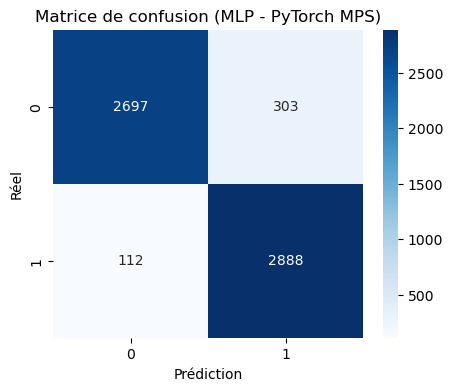

In [ ]:

# --------------------------------------------------------------
# 7️⃣ ÉVALUATION FINALE
# --------------------------------------------------------------
model.load_state_dict(torch.load("best_model_mps.pt"))
model.eval()
with torch.no_grad():
    y_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        y_pred.extend(outputs.cpu().numpy())
y_pred_bin = (np.array(y_pred).flatten() > 0.5).astype(int)

print("\n===== RAPPORT DE CLASSIFICATION =====")
print(classification_report(y_test, y_pred_bin))

cm = confusion_matrix(y_test, y_pred_bin)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion (MLP - PyTorch MPS)")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

# --------------------------------------------------------------
# 8️⃣ SAUVEGARDE DU RAPPORT
# --------------------------------------------------------------
with open("rapport_classification_torch.txt", "w", encoding="utf-8") as f:
    f.write("===== RAPPORT DE CLASSIFICATION (PyTorch M2 Pro) =====\n\n")
    f.write(classification_report(y_test, y_pred_bin))
    f.write(f"\nF1-score final : {best_f1:.4f}\n")
